# DFS value screen

**What this shows.** A daily-fantasy **value screen**: for one slate, join each player's salary to
their projection and rank by *points per $1,000 of salary*. Along the way it demonstrates a
**required filter set** — `dfs.slates` must be queried with **both** `operator_id` and `date`.

**Quota cost.** ~150 records (one ~70-player slate + its projections). Under a ~10k budget.

> **Setup.** Install deps (`pip install -r requirements.txt` plus the editable SDK — see the
> [README](../README.md)) and export your key once:
>
> ```bash
> export STAT_API_KEY=sdb_xxxxxxxx_...
> ```
>
> The client reads `STAT_API_KEY` from the environment. To run against a local mirror instead of
> production, also set `STAT_API_BASE_URL` (e.g. `http://localhost:3399`).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statapi import StatApi, ValidationError

api = StatApi()

OPERATOR_ID = 1
DATE = "2026-03-01"
SLATE_ID = 31619   # a 71-player, 2-game NBA classic slate on this date

## 1 · Slates need operator_id **and** date

Some tables require a specific combination of filters. `dfs.slates` is one: query it without the
`operator_id` + `date` pair and the API returns a `400 ValidationError` telling you which
combinations are accepted.

In [2]:
try:
    api.dfs.slates.list()                       # missing the required pair
except ValidationError as e:
    print("Without operator_id+date ->", type(e).__name__, e.status)

slates = api.dfs.slates.list(operator_id=OPERATOR_ID, date=DATE)
pd.DataFrame(
    [(s["id"], s["name"], s["start_time"]) for s in slates.rows],
    columns=["slate_id", "name", "start_time"],
).head(10)

Without operator_id+date -> ValidationError 400


,slate_id,name,start_time
0,31629,SAC @ LAL Showdown,2026-03-02T02:30:00+00:00
1,31628,Sun 9:00PM Snake,2026-03-02T02:00:00+00:00
2,31627,Sun 6:00PM Snake,2026-03-01T23:00:00+00:00
3,31626,MEM @ IND Showdown,2026-03-01T22:00:00+00:00
4,31625,Sun 3:30PM Snake,2026-03-01T20:30:00+00:00
5,31624,SAS @ NYK Showdown,2026-03-01T18:00:00+00:00
6,31620,Sun 6:00PM Single Stat - Points,2026-03-01T23:00:00+00:00
7,31619,Sun 9:00PM Classic,2026-03-02T02:00:00+00:00
8,31618,Sun 8:00PM Classic,2026-03-02T01:00:00+00:00
9,31617,PHI @ BOS Showdown,2026-03-02T01:00:00+00:00


## 2 · Slate players and salaries

In [3]:
players = list(api.dfs.slate_players.iter(slate_id=SLATE_ID))
pf = pd.DataFrame(players)
print(len(pf), "players on slate", SLATE_ID)
pf[["player_id", "display_name", "position", "salary", "team_id"]].sort_values("salary", ascending=False).head()

71 players on slate 31619


,player_id,display_name,position,salary,team_id
0,31,Luka Doncic,PG,11700,23
1,183,Kawhi Leonard,SG/SF,9700,22
2,470,LeBron James,PF,8500,23
3,310,Zion Williamson,PF,8400,29
4,289,Trey Murphy III,PG/SG,8000,29


## 3 · Join projections

Projections key off `slate_player_id`. When more than one source projects a player, we average
them.

In [4]:
def mean_projection(slate_player_id):
    rows = api.dfs.slate_player_projections.list(slate_player_id=slate_player_id).rows
    return sum(r["projection"] for r in rows) / len(rows) if rows else None

pf["projection"] = pf["id"].map(mean_projection)
pf = pf.dropna(subset=["projection"])
pf = pf[pf["salary"] > 0].copy()
print(len(pf), "players with a projection")

71 players with a projection


## 4 · Screen for value

**Value = projected points ÷ (salary / 1000)** — points per $1k. High-value plays let you afford
studs elsewhere in the lineup.

In [5]:
pf["value"] = pf["projection"] / (pf["salary"] / 1000)
screen = pf[pf["projection"] >= 5].sort_values("value", ascending=False)
screen[["display_name", "position", "salary", "projection", "value"]].head(20).round(2)

,display_name,position,salary,projection,value
24,Jeremiah Fears,PG/SG,4700,41.75,8.88
25,Jordan Miller,PG/SG,4600,40.00,8.70
17,Nique Clifford,SG/SF,5500,43.75,7.95
40,Luke Kennard,PG/SG,3500,24.75,7.07
55,Patrick Baldwin Jr.,SF/PF,3000,20.00,6.67
29,Marcus Smart,SG/SF,4400,28.25,6.42
65,Drew Eubanks,C,3000,19.00,6.33
20,Brook Lopez,C,5200,32.75,6.30
35,Yves Missi,C,3800,22.50,5.92
16,Derik Queen,C,5600,32.75,5.85


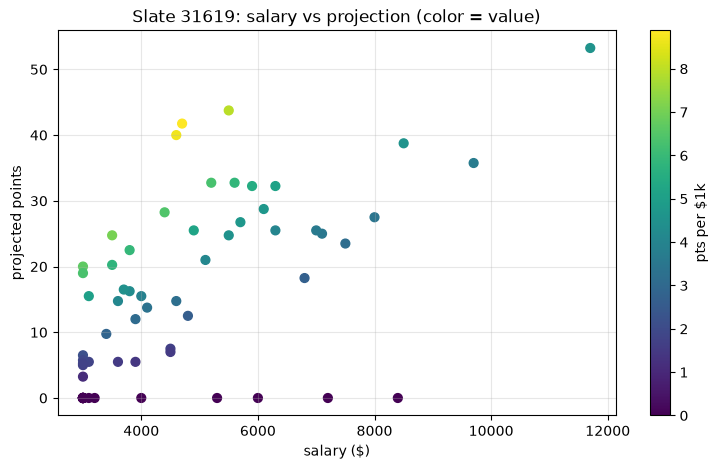

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(pf["salary"], pf["projection"], c=pf["value"], cmap="viridis", s=40)
ax.set_xlabel("salary ($)")
ax.set_ylabel("projected points")
ax.set_title(f"Slate {SLATE_ID}: salary vs projection (color = value)")
fig.colorbar(sc, label="pts per $1k")
ax.grid(alpha=0.3)
plt.show()

## Quota used

In [7]:
q = api.dfs.slates.list(operator_id=OPERATOR_ID, date=DATE, limit=1).quota
print(f"Records remaining this month: {q.remaining:,} of {q.limit:,}")

Records remaining this month: 34,630 of 50,000
